In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# The tests live in src/analysis.py so the notebook and the Streamlit app
# always report the same numbers.
sys.path.append('..')
from src import analysis as an

In [2]:
data = pd.read_csv('../data/marketing_AB.csv')

In [3]:
df = data.copy()

## **Decision Rule (written before the analysis)**

Fixing the rule up front stops the analysis from drifting towards whatever
result the data happens to support. Everything below is judged against this.

- **Primary metric:** conversion rate, one row per user.
- **Hypothesis:** one-sided, `H1: p_ad > p_psa`. The business question is whether the ad beats the PSA, and a worse ad would be shelved either way.
- **Significance level:** `alpha = 0.05`.
- **Practical threshold:** the campaign is only worth running if the true lift is at least **0.25 pp**. On a 1.79% baseline that is roughly a 14% relative lift, set to cover the operational cost of serving the campaign.
- **Ship only if both bars clear:** p-value below alpha **and** the lower bound of the 95% CI above 0.25 pp. Checking the lower bound rather than the point estimate stops a noisy win from passing.

One thing worth stating plainly about what is being measured. The control group
saw a **public service announcement, not a blank page**. So this experiment
estimates the value of the ad creative over a placebo ad, not the value of
advertising against no advertising at all.

##**Inspection**

In [4]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [6]:
df = df.drop(columns=['Unnamed: 0'])

# Sanity checks
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['user id'].duplicated().sum())  # check for duplicate users

(588101, 6)
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64
0


In [7]:
# 1. Check duplicate users
print("Duplicate users:", df['user id'].duplicated().sum())
print("Unique users:", df['user id'].nunique())
print("Total rows:", len(df))

# 2. Group sizes
group_counts = df['test group'].value_counts()

print("\nGroup Sizes:")
print(group_counts)

print("\nGroup Percentages:")
print((group_counts / len(df) * 100).round(2))

# 3. Overall conversions
total_conversions = df['converted'].sum()
total_users = len(df)
conversion_rate = df['converted'].mean()

print("\nOverall Conversions:")
print(f"Converted users: {total_conversions:,}")
print(f"Total users: {total_users:,}")
print(f"Overall conversion rate: {conversion_rate:.2%}")

group_summary = df.groupby('test group')['converted'].agg(
    users='count',
    conversions='sum',
    conversion_rate='mean'
)

group_summary['conversion_rate'] *= 100
print("\n")
print(group_summary)

Duplicate users: 0
Unique users: 588101
Total rows: 588101

Group Sizes:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Group Percentages:
test group
ad     96.0
psa     4.0
Name: count, dtype: float64

Overall Conversions:
Converted users: 14,843
Total users: 588,101
Overall conversion rate: 2.52%


             users  conversions  conversion_rate
test group                                      
ad          564577        14423         2.554656
psa          23524          420         1.785411


## **Sample Ratio Mismatch and Power**

Before testing the outcome, check that assignment itself worked. A sample ratio
mismatch means users did not arrive in the intended proportion, which usually
points to a bug in the assignment or logging rather than to a real effect. If
this check fails, nothing downstream can be trusted no matter how small the
p-value on conversion turns out to be.

The split here is deliberately uneven at 96/4, so the SRM check compares the
observed split against 96/4 rather than against 50/50.

In [8]:
counts = an.get_counts(df)

srm = an.srm_test(counts['n_ad'], counts['n_psa'])

print("Sample Ratio Mismatch Check")
print("-" * 40)
print(f"Observed ad share: {srm['observed_ad_share']:.4%}")
print(f"Intended ad share: {srm['expected_ad_share']:.0%}")
print(f"Chi-square: {srm['chi2']:.4f}")
print(f"P-value:    {srm['p_value']:.4f}")
print(f"Result:     {'PASS, no mismatch' if srm['passed'] else 'FAIL, investigate assignment'}")

Sample Ratio Mismatch Check
----------------------------------------
Observed ad share: 96.0000%
Intended ad share: 96%
Chi-square: 0.0000
P-value:    0.9998
Result:     PASS, no mismatch


In [9]:
baseline = counts['x_psa'] / counts['n_psa']

mde = an.minimum_detectable_effect(baseline, counts['n_ad'], counts['n_psa'])

print("Power / Minimum Detectable Effect")
print("-" * 55)
print(f"Control users:       {counts['n_psa']:,}")
print(f"Control conversions: {counts['x_psa']:,}")
print(f"Baseline rate:       {baseline:.4%}")
print()
print(f"MDE at 80% power:    {mde['mde_abs'] * 100:.3f} pp ({mde['mde_relative']:.1%} relative)")
print(f"MDE if split 50/50:  {mde['mde_abs_balanced'] * 100:.3f} pp")
print(f"Cost of the 96/4 split: {mde['mde_abs'] / mde['mde_abs_balanced']:.1f}x larger MDE")

Power / Minimum Detectable Effect
-------------------------------------------------------
Control users:       23,524
Control conversions: 420
Baseline rate:       1.7854%

MDE at 80% power:    0.219 pp (12.3% relative)
MDE if split 50/50:  0.086 pp
Cost of the 96/4 split: 2.6x larger MDE


### What these two checks tell us

**SRM:** the observed split is 96.00% against an intended 96%, `p = 0.9998`. There
is no evidence of a broken assignment or logging pipeline, so the comparison
below is worth making.

**Power:** only 23,524 users landed in control and just 420 of them converted.
The standard error of a difference is driven by whichever group is smaller, so
that control group sets the precision of the entire experiment. At 80% power and
a one-sided `alpha = 0.05` this design detects a lift of about **0.219 pp**.
Splitting the same 588,101 users evenly would have detected **0.086 pp**, roughly
**2.6x smaller**, for the same traffic.

The effect we end up measuring clears the MDE comfortably, so the imbalance did
not cost us the answer this time. It would have mattered for a smaller effect,
and rebalancing is the first thing to change in the next test.

##**Exploratory Data Analysis (EDA)**

In [10]:
# Overall distribution of total ads seen
print('Total Ads - Overall:')
print(df['total ads'].describe())
print()

# Distribution of total ads by experiment group
print('Total Ads - By Group:')
print(df.groupby('test group')['total ads'].describe())
print()

# Conversion rate by day with the most ads
print('Conversion Rate by Most Ads Day:')
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

by_day = (
    df.groupby('most ads day')['converted']
      .agg(['mean', 'count'])
      .reindex(day_order)
)

by_day['mean'] = by_day['mean'] * 100
by_day.rename(columns={
    'mean': 'conversion_rate',
    'count': 'users'
}, inplace=True)

print(by_day)
print()

# Conversion rate by hour with the most ads
print('Conversion Rate by Most Ads Hour:')
by_hour = df.groupby('most ads hour')['converted'].mean() * 100

print(by_hour)

Total Ads - Overall:
count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

Total Ads - By Group:
               count       mean        std  min  25%   50%   75%     max
test group                                                              
ad          564577.0  24.823365  43.750456  1.0  4.0  13.0  27.0  2065.0
psa          23524.0  24.761138  42.860720  1.0  4.0  12.0  26.0   907.0

Conversion Rate by Most Ads Day:
              conversion_rate  users
most ads day                        
Monday               3.281155  87073
Tuesday              2.984034  77479
Wednesday            2.494191  80908
Thursday             2.157094  82982
Friday               2.221190  92608
Saturday             2.105070  81660
Sunday               2.447565  85391

Conversion Rate by Most Ads Hour:
most ads hour
0     1.842486
1     1.291129
2 

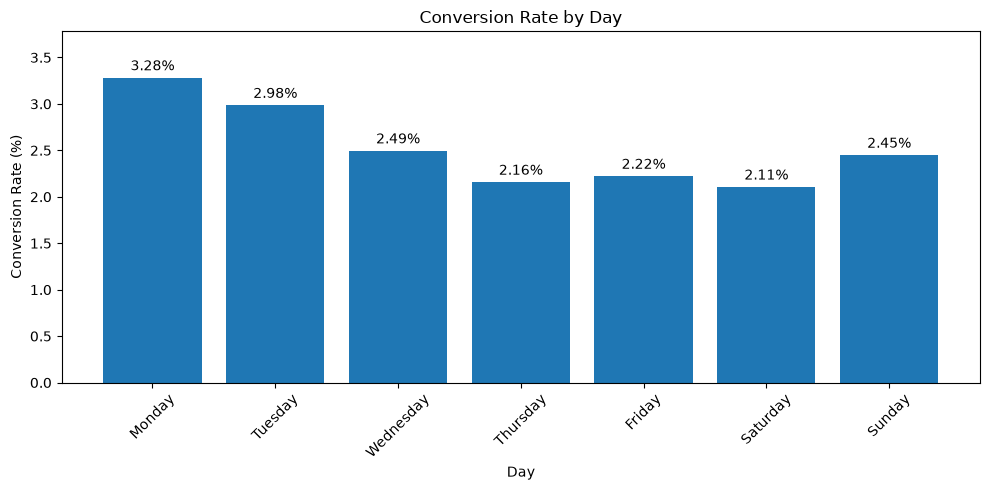

In [11]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

conversion_by_day = (
    df.groupby('most ads day')['converted']
      .mean()
      .reindex(day_order) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(conversion_by_day.index, conversion_by_day.values)

# Add percentage labels
ax.bar_label(
    bars,
    labels=[f'{v:.2f}%' for v in conversion_by_day.values],
    padding=3
)

ax.set_xlabel('Day')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Day')
ax.set_ylim(0, conversion_by_day.max() + 0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

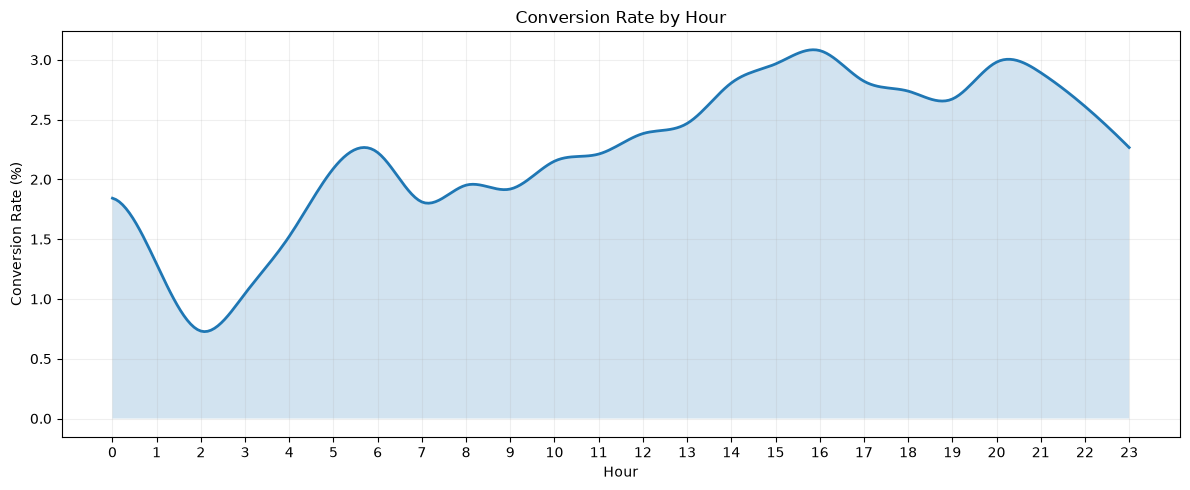

In [12]:
from scipy.interpolate import make_interp_spline

conversion_by_hour = (
    df.groupby('most ads hour')['converted']
      .mean() * 100
)

x = conversion_by_hour.index.values
y = conversion_by_hour.values

# Smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Plot
plt.figure(figsize=(12, 5))

plt.plot(x_smooth, y_smooth, linewidth=2)
plt.fill_between(x_smooth, y_smooth, alpha=0.2)

plt.xlabel('Hour')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Hour')

plt.xticks(range(0, 24))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Exploratory Analysis

- **Ad exposure distribution:** `total ads` looks nearly identical across the two arms, both averaging about 24.8 ads with similar quartiles. Worth noting that this is an outcome of the experiment, not a property of the assignment, so it is treated as a diagnostic later rather than as a balance check.

- **Right-skewed ad exposure:** `total ads` is heavily right-skewed. The median is 13 against a mean of about 24.8, and the maximum reaches 2,065. A small number of users saw an enormous number of ads, which is why a plain t-test is not used on this column later.

- **Conversion rate by day:** conversion varies across the week, peaking Monday and Tuesday near 3% and dipping to about 2.1% to 2.2% on Thursday and Saturday.

- **Conversion rate by hour:** conversion is lowest overnight, around 0.7% at 2 AM, then climbs through the day to roughly 3% between 4 PM and 8 PM.

> **Important:** these day and hour patterns pool both groups together, so they
> describe when people convert in general, not when ads work better. Nothing
> here says anything about the treatment effect. The per-day effect is tested
> properly, with intervals and a multiple-comparison correction, at the end of
> the notebook.

## **Post-Treatment Diagnostics**

A note on what this section is and is not.

`total ads`, `most ads day` and `most ads hour` are all recorded **while the
campaign is running**, so the treatment itself can change them. A variable
measured after assignment cannot be used to validate that assignment, and
conditioning on one can introduce bias instead of removing it. Calling these
"covariate balance checks" would be wrong.

They are still worth looking at as descriptive diagnostics, because a large gap
in exposure would suggest the two arms were delivered very differently. But the
actual randomisation evidence is the SRM check above, not this section.

The dataset has no pre-treatment fields at all, no age, tenure, past purchases
or acquisition channel. A real balance table cannot be built from this data, and
a covariate-adjusted estimate such as CUPED is off the table for the same
reason.

In [13]:
# 1. Compare total ads distribution between groups
# Mann-Whitney U is used because total ads is heavily right-skewed
ad_total = df[df['test group'] == 'ad']['total ads']
psa_total = df[df['test group'] == 'psa']['total ads']

u_stat, p_mw = stats.mannwhitneyu(
    ad_total,
    psa_total,
    alternative='two-sided'
)

print('Mann-Whitney U test on total ads (ad vs psa):')
print(f'  p-value = {p_mw:.4f}')
print()

# 2. Chi-square test: Is most ads day independent of test group?
day_ct = pd.crosstab(
    df['test group'],
    df['most ads day']
)

chi2, p_day, dof, expected = stats.chi2_contingency(day_ct)

print('Chi-square test: most ads day vs test group:')
print(f'  chi2 = {chi2:.2f}, p-value = {p_day:.4f}')
print()

# 3. Chi-square test: Is most ads hour independent of test group?
hour_ct = pd.crosstab(
    df['test group'],
    df['most ads hour']
)

chi2h, p_hour, dofh, expected_hour = stats.chi2_contingency(hour_ct)

print('Chi-square test: most ads hour vs test group:')
print(f'  chi2 = {chi2h:.2f}, p-value = {p_hour:.4f}')

Mann-Whitney U test on total ads (ad vs psa):
  p-value = 0.0000

Chi-square test: most ads day vs test group:
  chi2 = 235.61, p-value = 0.0000

Chi-square test: most ads hour vs test group:
  chi2 = 192.29, p-value = 0.0000


### Test Results

All three tests come back with tiny p-values:

- **Total ads:** Mann-Whitney U gives `p < 0.001`. Mann-Whitney is used rather than a t-test because `total ads` is heavily right-skewed.
- **Most ads day:** chi-square gives `chi2 = 235.61`, `p < 0.001`.
- **Most ads hour:** chi-square gives `chi2 = 192.29`, `p < 0.001`.

Read on their own these look alarming. They are not, and the next cell shows
why. With 588K rows a difference of almost any size becomes "significant", so
the p-value stops carrying information about whether a gap actually matters.
Effect sizes are needed to answer that.

In [14]:
diag = an.post_treatment_diagnostics(df)

print("Total Ads Comparison")
print("-" * 40)
print(f"Median total ads - Ad:  {diag['ad_median']:.1f}")
print(f"Median total ads - PSA: {diag['psa_median']:.1f}")
print(f"Mean total ads   - Ad:  {diag['ad_mean']:.2f}")
print(f"Mean total ads   - PSA: {diag['psa_mean']:.2f}")
print(f"Mann-Whitney U p-value: {diag['mannwhitney_p']:.2e}")
print()

print("Effect Sizes (Cramer's V)")
print("-" * 40)
print(f"Most ads day vs test group:  {diag['cramers_v_day']:.4f}")
print(f"Most ads hour vs test group: {diag['cramers_v_hour']:.4f}")

Total Ads Comparison
----------------------------------------
Median total ads - Ad:  13.0
Median total ads - PSA: 12.0
Mean total ads   - Ad:  24.82
Mean total ads   - PSA: 24.76
Mann-Whitney U p-value: 4.69e-11

Effect Sizes (Cramer's V)
----------------------------------------
Most ads day vs test group:  0.0200
Most ads hour vs test group: 0.0181


### Interpretation and Conclusion

The effect sizes tell a completely different story from the p-values. Cramér's V
is `0.0200` for day and `0.0181` for hour, both negligible. Median `total ads` is
13 against 12, and the means differ by about 0.06 ads out of roughly 25. These
are gaps you would struggle to care about in any practical sense, which is
exactly why effect sizes are reported next to the p-values here.

**Conclusion:** exposure patterns look practically identical across the two
arms. That is reassuring, but it describes what happened during the experiment
rather than proving assignment was random. It should be read alongside the SRM
result, not instead of it.

##**Run the significance test**

In [15]:
test = an.two_proportion_test(**counts)
rel = an.relative_lift_ci(**counts)

print("Conversion Rates")
print("-" * 55)
print(f"Ad:  {test['p_ad']:.5f} ({counts['x_ad']:,}/{counts['n_ad']:,})")
print(f"PSA: {test['p_psa']:.5f} ({counts['x_psa']:,}/{counts['n_psa']:,})")
print()

print("Two-Proportion Z-Test (H1: p_ad > p_psa)")
print("-" * 55)
print(f"Z-statistic:       {test['z_stat']:.4f}")
print(f"One-sided p-value: {test['p_one_sided']:.2e}")
print(f"Two-sided p-value: {test['p_two_sided']:.2e}")
print()

print("Absolute Difference")
print("-" * 55)
print(f"Difference (Ad - PSA): {test['diff'] * 100:.3f} pp")
print(f"95% CI (Newcombe):     [{test['ci_low'] * 100:.3f} pp, {test['ci_high'] * 100:.3f} pp]")
print()

print("Relative Lift")
print("-" * 55)
print(f"Relative lift: {rel['lift']:.1%}")
print(f"95% CI:        [{rel['lift_low']:.1%}, {rel['lift_high']:.1%}]")
print()

# Cross-check. The chi-square test on the same 2x2 table is mathematically
# equivalent to the two-sided z-test, so the p-values should agree.
ct = pd.crosstab(df['test group'], df['converted'])
chi2, p_chi2, dof, expected = chi2_contingency(ct, correction=False)

print("Chi-Square Cross-Check")
print("-" * 55)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value:              {p_chi2:.2e}")

Conversion Rates
-------------------------------------------------------
Ad:  0.02555 (14,423/564,577)
PSA: 0.01785 (420/23,524)

Two-Proportion Z-Test (H1: p_ad > p_psa)
-------------------------------------------------------
Z-statistic:       7.3701
One-sided p-value: 8.53e-14
Two-sided p-value: 1.71e-13

Absolute Difference
-------------------------------------------------------
Difference (Ad - PSA): 0.769 pp
95% CI (Newcombe):     [0.587 pp, 0.936 pp]

Relative Lift
-------------------------------------------------------
Relative lift: 43.1%
95% CI:        [30.0%, 57.5%]

Chi-Square Cross-Check
-------------------------------------------------------
Chi-square statistic: 54.32
P-value:              1.71e-13


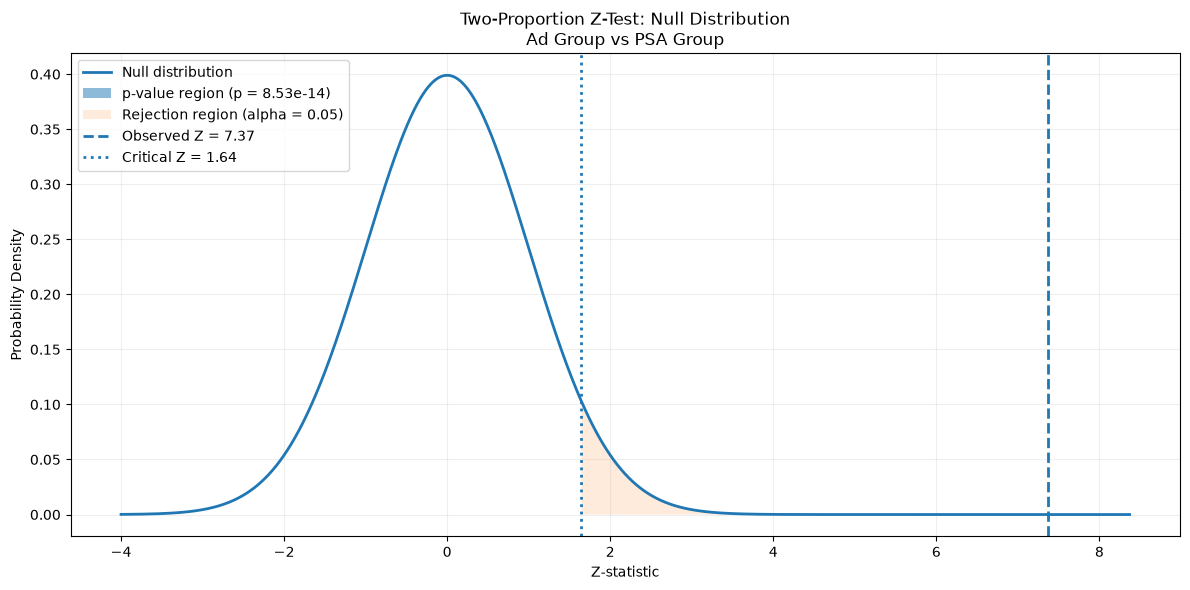

In [16]:
z_stat = test['z_stat']
z_critical = test['z_critical']

z = np.linspace(-4, max(5, z_stat + 1), 3000)

plt.figure(figsize=(12, 6))
plt.plot(z, stats.norm.pdf(z), linewidth=2, label='Null distribution')

z_pvalue = z[z >= z_stat]
plt.fill_between(
    z_pvalue,
    stats.norm.pdf(z_pvalue),
    0,
    alpha=0.5,
    label=f"p-value region (p = {test['p_one_sided']:.2e})"
)

z_rejection = z[z >= z_critical]
plt.fill_between(
    z_rejection,
    stats.norm.pdf(z_rejection),
    0,
    alpha=0.15,
    label=f'Rejection region (alpha = {an.ALPHA})'
)

plt.axvline(z_stat, linestyle='--', linewidth=2, label=f'Observed Z = {z_stat:.2f}')
plt.axvline(z_critical, linestyle=':', linewidth=2, label=f'Critical Z = {z_critical:.2f}')

plt.xlabel('Z-statistic')
plt.ylabel('Probability Density')
plt.title('Two-Proportion Z-Test: Null Distribution\nAd Group vs PSA Group')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
verdict = an.decision(test)

print("Verdict Against the Pre-Registered Rule")
print("-" * 55)
print(f"Statistical bar (p < {an.ALPHA}):        {'PASS' if verdict['stat_pass'] else 'FAIL'}"
      f"  [p = {test['p_one_sided']:.2e}]")
print(f"Practical bar (CI low > {verdict['threshold_pp']} pp): {'PASS' if verdict['practical_pass'] else 'FAIL'}"
      f"  [CI low = {test['ci_low'] * 100:.3f} pp]")
print()
print(f"Recommendation: {'SHIP the ad campaign' if verdict['ship'] else 'DO NOT ship on this evidence'}")

Verdict Against the Pre-Registered Rule
-------------------------------------------------------
Statistical bar (p < 0.05):        PASS  [p = 8.53e-14]
Practical bar (CI low > 0.25 pp): PASS  [CI low = 0.587 pp]

Recommendation: SHIP the ad campaign


### Verdict: Statistically Significant and Practically Meaningful

The one-sided p-value is `8.53e-14`, far below `alpha = 0.05`, so the null of
equal conversion rates is rejected. The chi-square cross-check agrees, which it
has to, since the two tests are mathematically equivalent for a 2x2 table.

With 588K rows a trivial difference would also have been "significant", so the
p-value alone settles very little. What matters is the interval. The 95% CI on
the difference is **[0.587 pp, 0.936 pp]**, and its lower bound sits above the
0.25 pp threshold fixed before the analysis. Both bars clear, so the
pre-registered rule says ship.

**On the confidence interval method.** Newcombe is used rather than Wald. Both
conversion rates are under 3% and the control group has only 420 conversions,
and in that corner the Wald interval is known to fall short of its stated 95%
coverage.

**On the relative lift.** The headline number people repeat is the 43% relative
lift, and it needs its own interval. A ratio is not a linear function of a
difference, so the interval on the difference cannot simply be rescaled.
Computed on the log ratio scale it comes out at **[30.0%, 57.5%]**. That is
wide. The honest summary is not "ads lift conversion by 43%", it is "somewhere
between a 30% and a 58% lift, most likely near 43%". The width traces straight
back to the small control group.

##**Business Impact**

In [18]:
impact = an.business_impact(test, counts['n_ad'])

print("Incremental Conversions")
print("-" * 55)
print(f"Point estimate: {impact['incremental_point']:,.0f}")
print(f"95% CI:         {impact['incremental_low']:,.0f} - {impact['incremental_high']:,.0f}")
print()

print("Revenue Sensitivity Analysis")
print("-" * 70)
print("No price or margin column exists in the data, so revenue is shown")
print("across a range of assumed margins instead of one invented number.")
print()

for _, row in impact['revenue'].iterrows():
    print(
        f"Margin per conversion {row['Margin per conversion']:>5}: "
        f"${row['Point estimate']:>12,.0f} "
        f"(95% CI: ${row['CI low']:,.0f} - ${row['CI high']:,.0f})"
    )

Incremental Conversions
-------------------------------------------------------
Point estimate: 4,343
95% CI:         3,316 - 5,284

Revenue Sensitivity Analysis
----------------------------------------------------------------------
No price or margin column exists in the data, so revenue is shown
across a range of assumed margins instead of one invented number.

Margin per conversion   $20: $      86,860 (95% CI: $66,320 - $105,689)
Margin per conversion   $50: $     217,149 (95% CI: $165,800 - $264,223)
Margin per conversion  $100: $     434,298 (95% CI: $331,600 - $528,446)
Margin per conversion  $200: $     868,596 (95% CI: $663,200 - $1,056,891)


### 1. Incremental Conversions

Rather than leaning on the point estimate alone, the 95% CI on the difference
gives a defensible range for the incremental conversions.

| Estimate | Incremental Conversions |
|---|---:|
| Point estimate | ~4,343 |
| 95% CI | 3,316 - 5,284 |

Across the 564,577 users in the `ad` group, the treatment generated roughly
**3,316 to 5,284 additional conversions**, with about 4,343 as the point
estimate.

### 2. Revenue Sensitivity Analysis

The dataset has no revenue, price or margin column, so a single revenue figure
would be invented rather than estimated. A sensitivity table across plausible
margins is the honest version, and it lets whoever owns the number plug in
their own.

### 3. Does the lift hold on every day of the week?

The next cell splits the effect by day. Two things are done properly there that
are easy to skip:

- Every day gets a **confidence interval**, not just a point lift.
- The seven p-values are corrected with the **Holm method**. Running one test per day means seven chances to find something by luck, and Holm controls the family-wise error rate while being uniformly more powerful than Bonferroni.

In [19]:
segments = an.segment_lifts(df)

report = pd.DataFrame({
    'Day': segments['segment'],
    'Ad rate': segments['ad_rate'].map('{:.2%}'.format),
    'PSA rate': segments['psa_rate'].map('{:.2%}'.format),
    'Control users': segments['psa_users'],
    'Lift (pp)': segments['lift_pp'].map('{:+.2f}'.format),
    '95% CI (pp)': [
        f'[{lo:+.2f}, {hi:+.2f}]'
        for lo, hi in zip(segments['ci_low_pp'], segments['ci_high_pp'])
    ],
    'p raw': segments['p_raw'].map('{:.4f}'.format),
    'p Holm': segments['p_holm'].map('{:.4f}'.format),
    'Holds up': np.where(segments['significant'], 'Yes', 'No'),
})

print(report.to_string(index=False))

      Day Ad rate PSA rate  Control users Lift (pp)    95% CI (pp)  p raw p Holm Holds up
   Monday   3.32%    2.26%           3502     +1.07 [+0.51, +1.53] 0.0005 0.0025      Yes
  Tuesday   3.04%    1.44%           2907     +1.60 [+1.08, +1.99] 0.0000 0.0000      Yes
Wednesday   2.54%    1.58%           3490     +0.96 [+0.48, +1.34] 0.0004 0.0023      Yes
 Thursday   2.16%    2.02%           3905     +0.14 [-0.36, +0.55] 0.5548 0.5548       No
   Friday   2.25%    1.63%           3803     +0.62 [+0.15, +0.99] 0.0116 0.0347      Yes
 Saturday   2.13%    1.40%           2858     +0.73 [+0.22, +1.12] 0.0075 0.0299      Yes
   Sunday   2.46%    2.06%           3059     +0.40 [-0.17, +0.86] 0.1572 0.3144       No


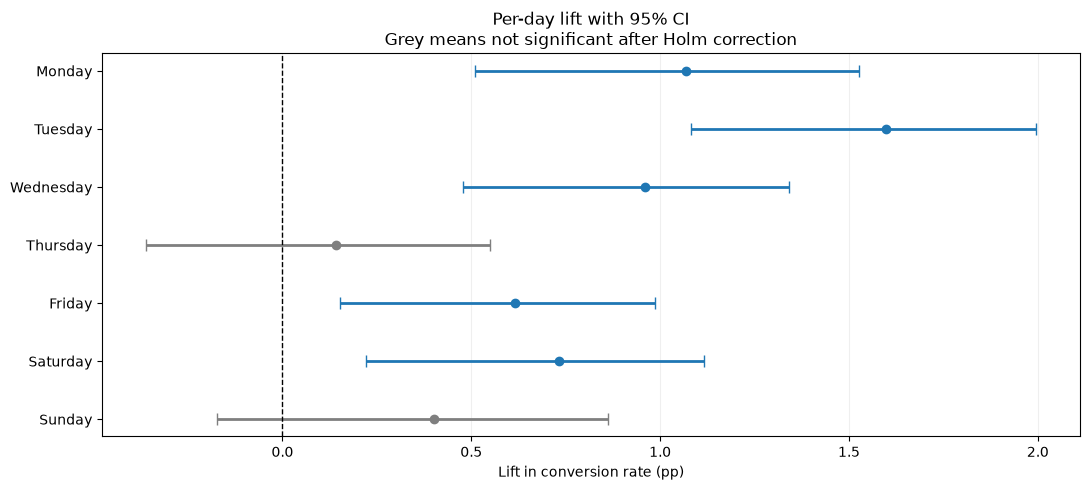

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))

# errorbar takes one colour per call, so each day is drawn separately.
for i, row in segments.iterrows():
    color = 'tab:blue' if row['significant'] else 'tab:gray'
    ax.errorbar(
        row['lift_pp'],
        i,
        xerr=[[row['lift_pp'] - row['ci_low_pp']], [row['ci_high_pp'] - row['lift_pp']]],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=2,
        capsize=4,
    )

ax.axvline(0, linestyle='--', linewidth=1, color='black')
ax.set_yticks(np.arange(len(segments)))
ax.set_yticklabels(segments['segment'])
ax.invert_yaxis()
ax.set_xlabel('Lift in conversion rate (pp)')
ax.set_title('Per-day lift with 95% CI\nGrey means not significant after Holm correction')
ax.grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

### What the per-day breakdown actually says

**5 of 7 days** still show a significant lift after the Holm correction.
**Thursday and Sunday** do not, and their intervals cross zero.

That is not evidence that ads stop working midweek. Each day carries only about
3,000 control users, so the per-day intervals are wide and the two null results
are mostly a statement about sample size. Notice also that the raw p-value for
Friday is `0.0116`, which would look convincing on its own, but after correcting
for seven tests it moves to `0.0347`. Still significant here, but the gap shows
how easily an uncorrected segment scan manufactures findings.

Treat this as a hypothesis for the next experiment rather than a scheduling
decision. Claiming the effect genuinely varies by day needs a formal
day-by-treatment interaction test, which is not run here.

### Stakeholder Summary

> Replacing the PSA with the ad increased conversion by **0.77 pp**
> (95% CI **0.59 to 0.94 pp**), a relative lift of **43%**
> (95% CI **30% to 58%**), with `p < 0.001`. That is roughly **4,343 extra
> conversions** across 564,577 users. The result clears both the statistical bar
> and the 0.25 pp practical bar set before the analysis, so the recommendation
> is to ship.
>
> Two caveats to carry into the next test. The control group was only 4% of
> traffic, which is why the relative lift interval is as wide as it is.
> And the control saw a PSA rather than nothing, so this measures the ad against
> a placebo ad, not against no advertising at all.

### Limitations

- No pre-treatment covariates exist in the data, so randomisation can only be checked through the SRM test and no covariate-adjusted estimate (logistic regression, CUPED) is possible.
- The exposure variables are post-treatment, so they are reported as diagnostics rather than balance checks.
- Day-of-week differences are tested per segment with a Holm correction, but no formal interaction test is run.
- The data has no calendar dates, only day of week, so novelty effects and time trends over the campaign cannot be checked.